In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np

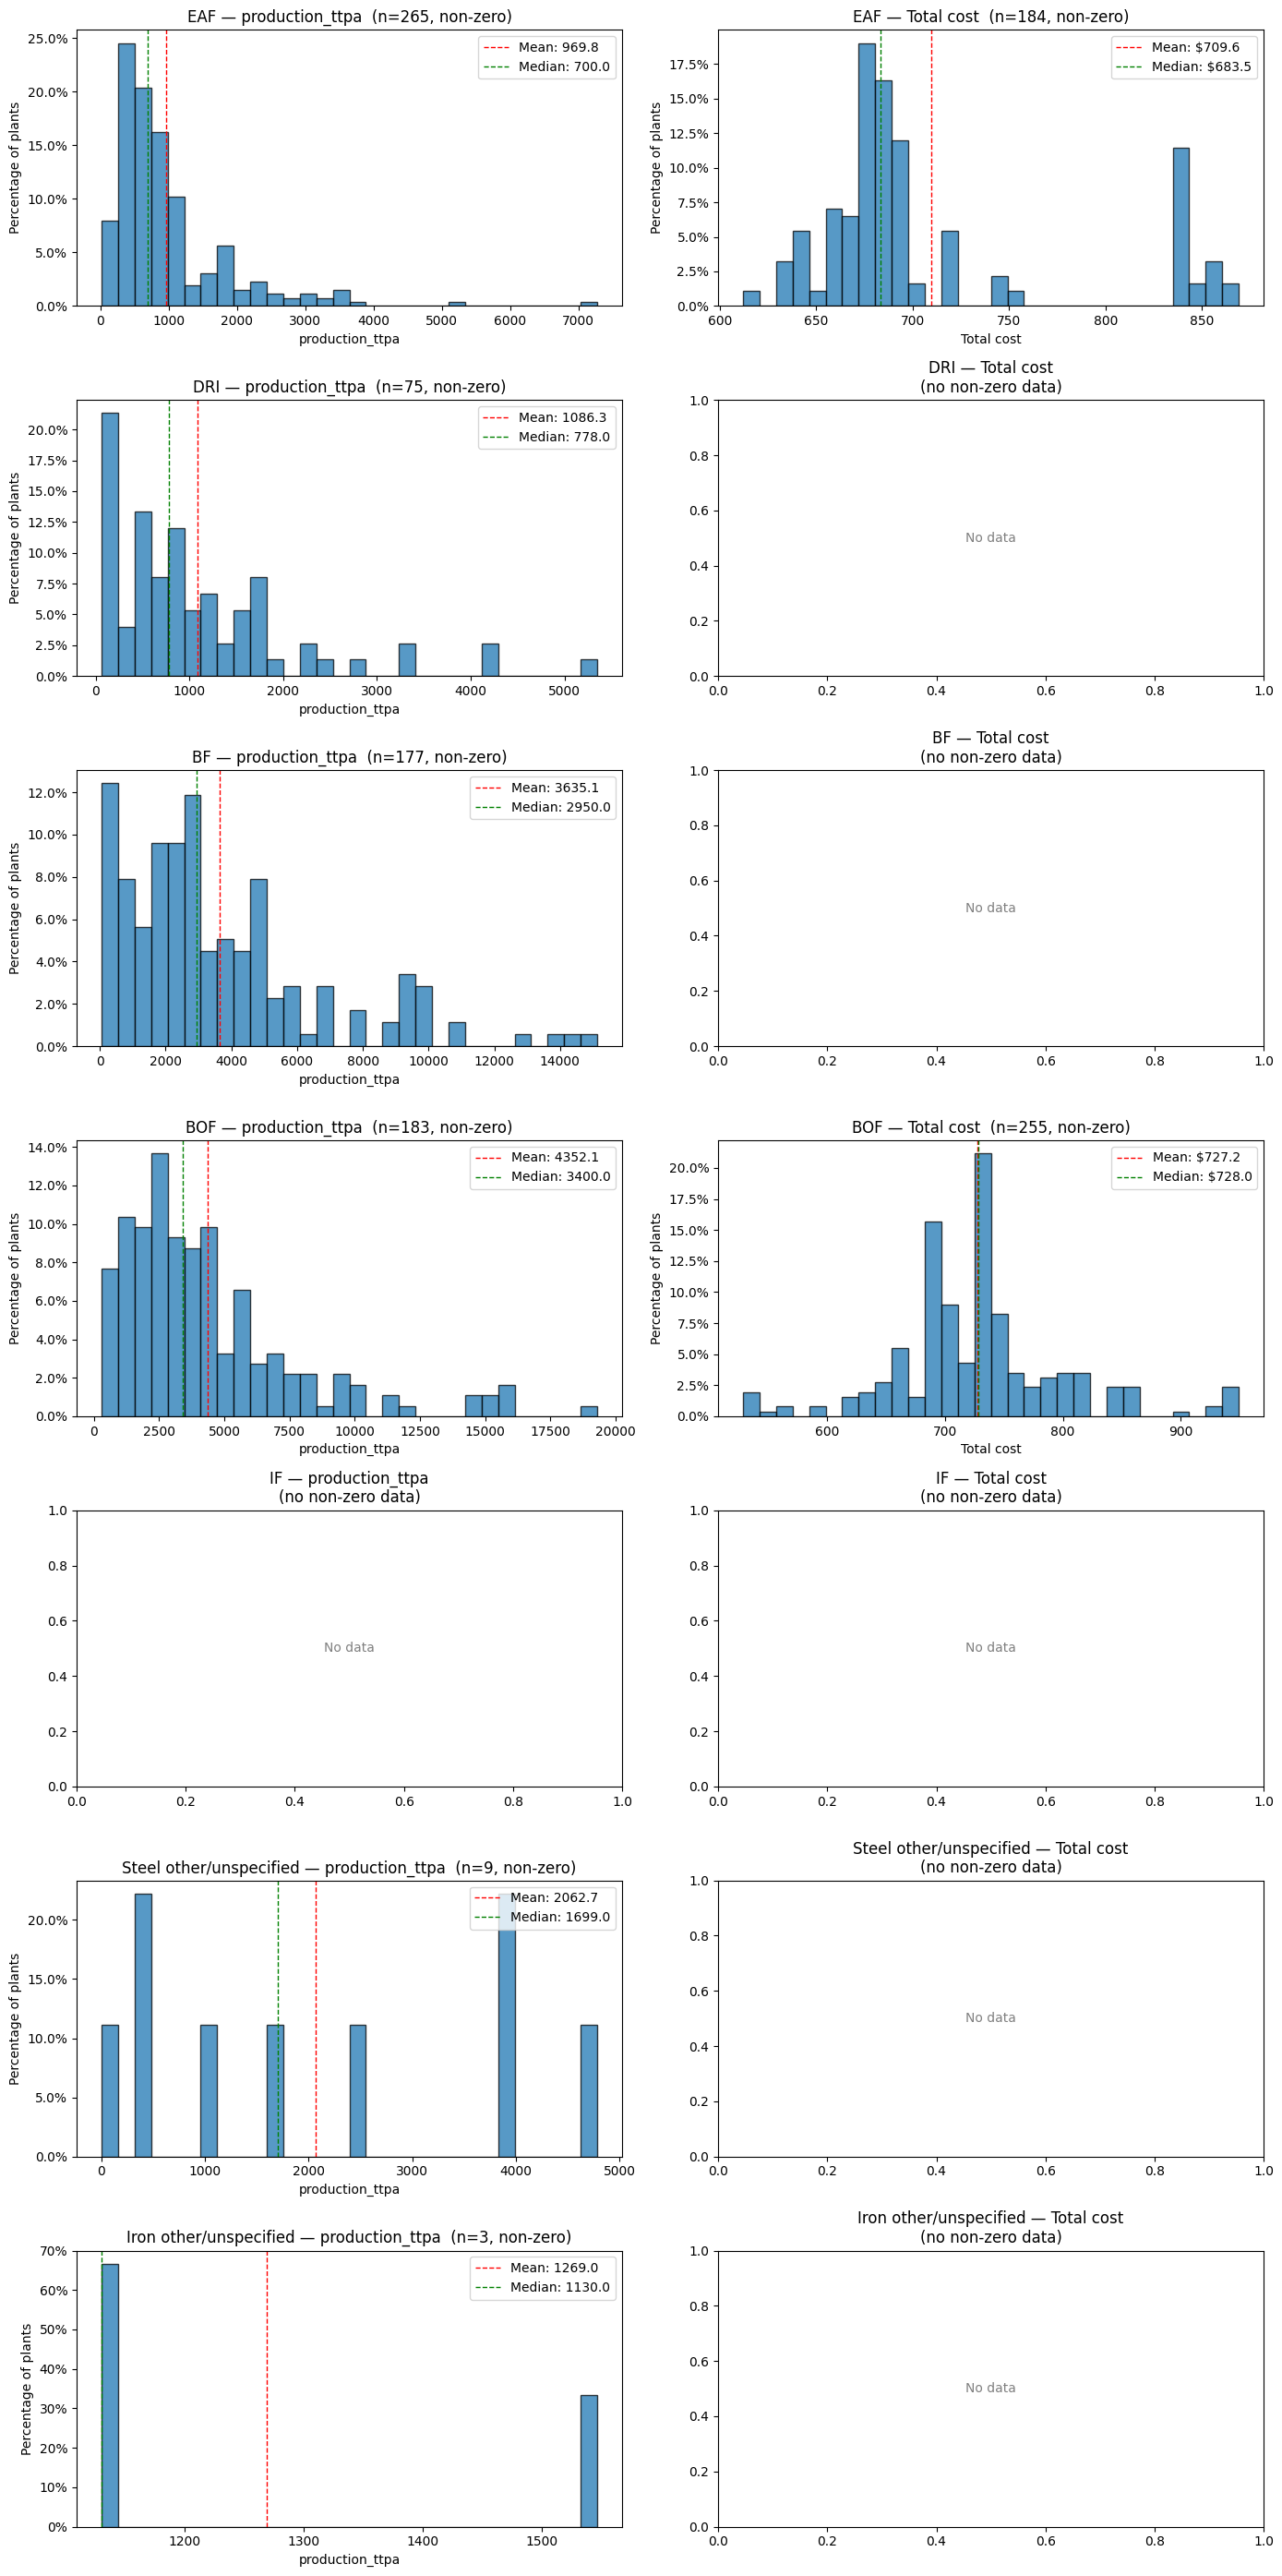

In [8]:
steel_df = pd.read_excel('../data/Processed_Data/steel_property_cost_merged.xlsx', sheet_name='Sheet1')
steel_df[steel_df['Total cost']!=0]['Plant name (English)'].nunique()

def plot_histograms(df, equipment_types, metrics,
                    group_col='Main production equipment',
                    drop_zero=True):
    n_rows = len(equipment_types)
    n_cols = len(metrics)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(7 * n_cols, 4 * n_rows))
    # Ensure axes is always 2D for consistent indexing
    axes = np.atleast_2d(axes).reshape(n_rows, n_cols)

    for i, equip_type in enumerate(equipment_types):
        for j, metric in enumerate(metrics):
            ax = axes[i, j]
            data = pd.to_numeric(
                df.loc[df[group_col] == equip_type, metric],
                errors='coerce'
            ).dropna()

            # Use only non-zero data points
            if drop_zero:
                data = data[data != 0]

            if data.empty:
                ax.set_title(f'{equip_type} — {metric}\n(no non-zero data)')
                ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                        transform=ax.transAxes, color='gray')
                continue

            # Dollar prefix only for cost metrics (case-insensitive)
            prefix = '$' if '$' in metric or 'cost' in metric.lower() else ''

            # Weight each observation so bar heights sum to 100%
            weights = np.ones(len(data)) / len(data) * 100
            ax.hist(data, bins=30, weights=weights,
                    edgecolor='black', alpha=0.75)
            ax.yaxis.set_major_formatter(PercentFormatter())

            ax.set_xlabel(metric)
            ax.set_ylabel('Percentage of plants')
            ax.set_title(f'{equip_type} — {metric}  (n={len(data)}, non-zero)')
            ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1,
                       label=f'Mean: {prefix}{data.mean():.1f}')
            ax.axvline(data.median(), color='green', linestyle='--', linewidth=1,
                       label=f'Median: {prefix}{data.median():.1f}')
            ax.legend()

    fig.tight_layout()
    plt.show()


equipment_types = list(steel_df['Main production equipment'].unique())
metrics = ['production_ttpa', 'Total cost']

plot_histograms(steel_df, equipment_types, metrics)

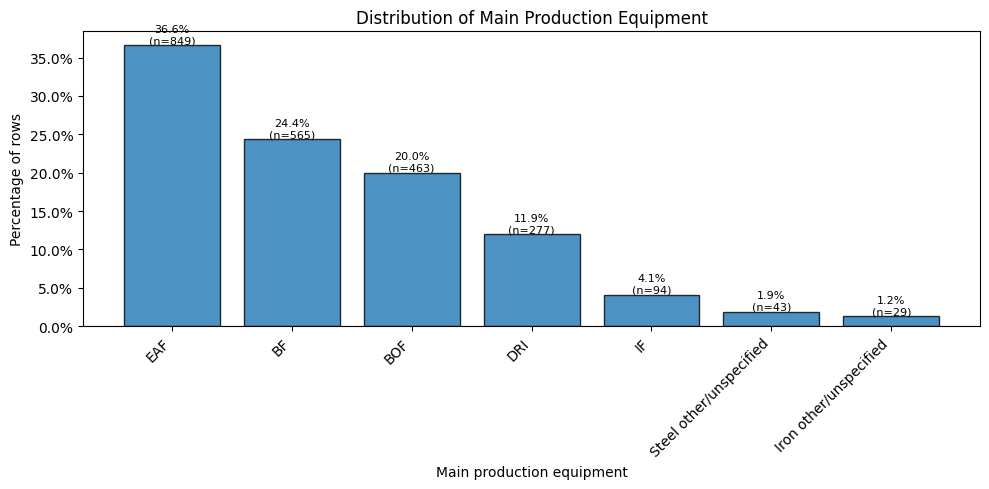

In [9]:
# Percentage share of each equipment type
counts = steel_df['Main production equipment'].value_counts(dropna=False)
pct = counts / counts.sum() * 100

plt.figure(figsize=(10, 5))
bars = plt.bar(pct.index.astype(str), pct.values,
               edgecolor='black', alpha=0.8)

plt.gca().yaxis.set_major_formatter(PercentFormatter())
plt.xlabel('Main production equipment')
plt.ylabel('Percentage of rows')
plt.title('Distribution of Main Production Equipment')
plt.xticks(rotation=45, ha='right')

# Annotate each bar with its percentage
for bar, p, c in zip(bars, pct.values, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{p:.1f}%\n(n={c})', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()